In [1]:
# ============================================
# CELDA 1: Importaciones
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import (classification_report, 
                              confusion_matrix,
                              precision_recall_curve,
                              roc_curve, auc)
import warnings
warnings.filterwarnings('ignore')

# Cargamos modelos y datos
with open('../src/model/isolation_forest.pkl', 'rb') as f:
    model = pickle.load(f)

with open('../src/model/pca_model.pkl', 'rb') as f:
    pca = pickle.load(f)

X       = pd.read_csv('../data/X_processed.csv')
y       = pd.read_csv('../data/y_labels.csv')['label']
preds   = pd.read_csv('../data/predictions.csv')

y_pred         = preds['prediction']
anomaly_scores = preds['anomaly_score']

print("✅ Todo cargado correctamente")
print(f"📊 Muestras: {len(X):,}")

✅ Todo cargado correctamente
📊 Muestras: 1,567


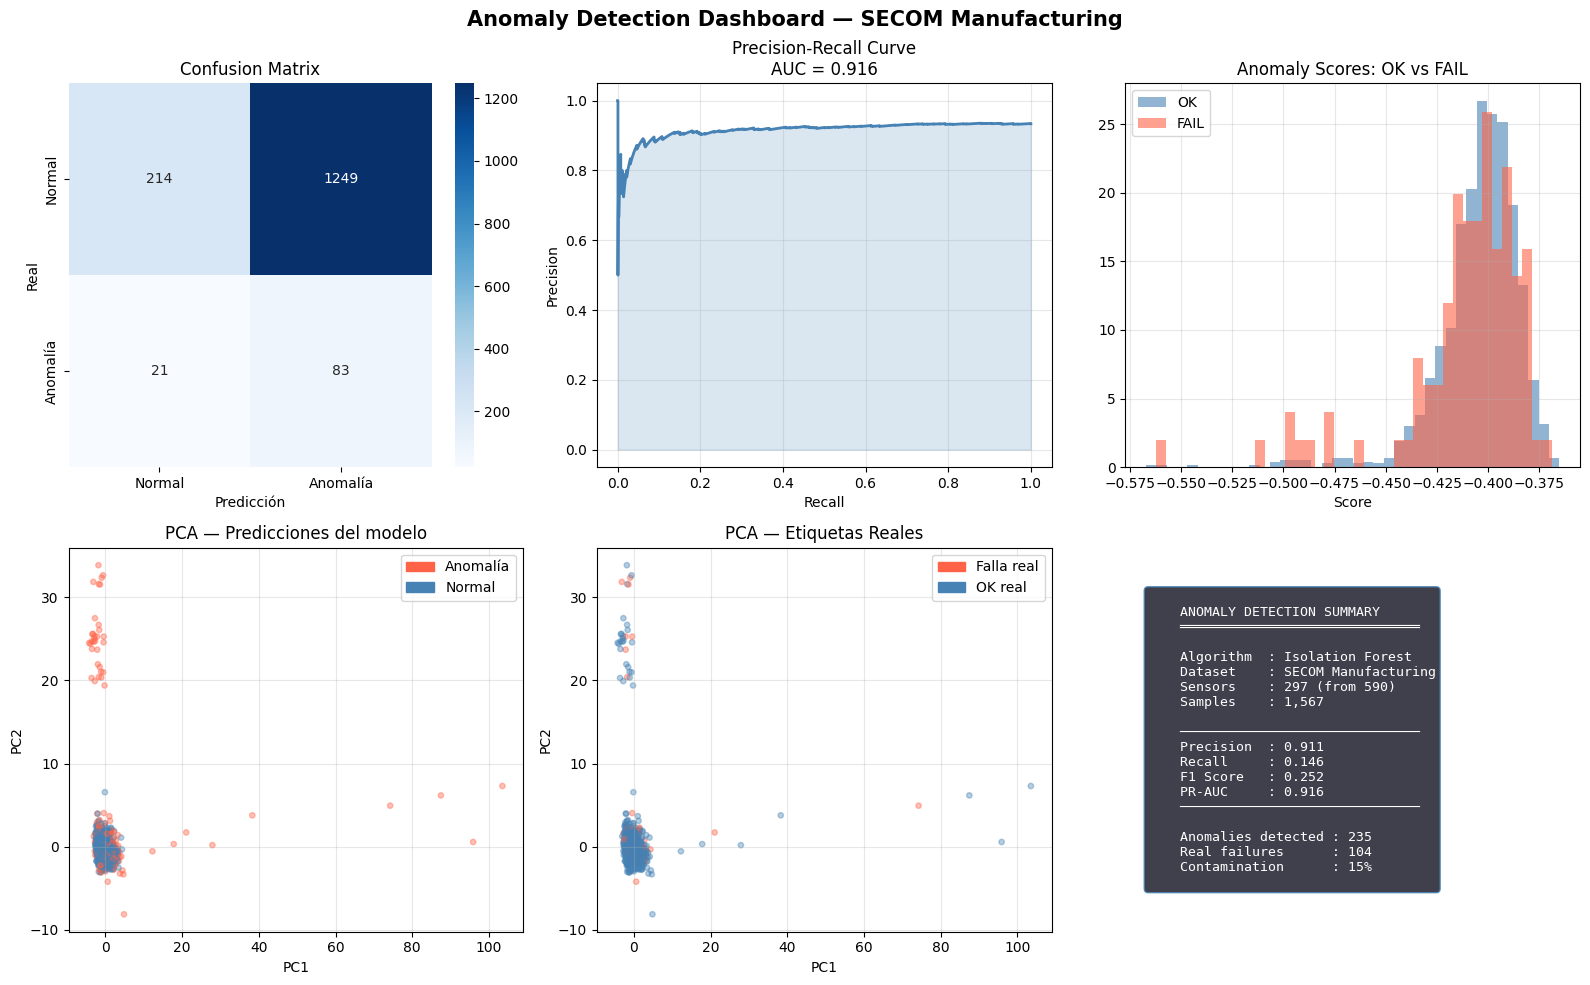

✅ Dashboard guardado


In [2]:
# ============================================
# CELDA 2: Dashboard de evaluación
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Anomaly Detection Dashboard — SECOM Manufacturing',
             fontsize=15, fontweight='bold')

# ── Gráfica 1: Confusion Matrix ──────────────
ax1 = axes[0, 0]
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomalía'],
            yticklabels=['Normal', 'Anomalía'], ax=ax1)
ax1.set_title('Confusion Matrix')
ax1.set_ylabel('Real')
ax1.set_xlabel('Predicción')

# ── Gráfica 2: Precision-Recall Curve ────────
ax2 = axes[0, 1]
# Convertimos etiquetas para la curva (1=falla, 0=ok)
y_binary = (y == -1).astype(int)
scores_inv = -anomaly_scores  # invertimos para que mayor = más anómalo
precision_curve, recall_curve, _ = precision_recall_curve(
    y_binary, scores_inv)
pr_auc = auc(recall_curve, precision_curve)
ax2.plot(recall_curve, precision_curve,
         color='steelblue', linewidth=2)
ax2.fill_between(recall_curve, precision_curve,
                 alpha=0.2, color='steelblue')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title(f'Precision-Recall Curve\nAUC = {pr_auc:.3f}')
ax2.grid(True, alpha=0.3)

# ── Gráfica 3: Anomaly Score por clase ───────
ax3 = axes[0, 2]
scores_ok   = anomaly_scores[y == -1]
scores_fail = anomaly_scores[y ==  1]
ax3.hist(scores_ok, bins=40, alpha=0.6,
         color='steelblue', label='OK', density=True)
ax3.hist(scores_fail, bins=40, alpha=0.6,
         color='tomato', label='FAIL', density=True)
ax3.set_title('Anomaly Scores: OK vs FAIL')
ax3.set_xlabel('Score')
ax3.legend()
ax3.grid(True, alpha=0.3)

# ── Gráfica 4: PCA predicciones ──────────────
ax4 = axes[1, 0]
X_2d = pca.transform(X)
colors = ['tomato' if p == -1 else 'steelblue' for p in y_pred]
ax4.scatter(X_2d[:, 0], X_2d[:, 1],
            c=colors, alpha=0.4, s=15)
ax4.set_title('PCA — Predicciones del modelo')
ax4.set_xlabel('PC1')
ax4.set_ylabel('PC2')
from matplotlib.patches import Patch
ax4.legend(handles=[Patch(color='tomato', label='Anomalía'),
                    Patch(color='steelblue', label='Normal')])
ax4.grid(True, alpha=0.3)

# ── Gráfica 5: PCA etiquetas reales ──────────
ax5 = axes[1, 1]
colors_real = ['tomato' if p == 1 else 'steelblue' for p in y]
ax5.scatter(X_2d[:, 0], X_2d[:, 1],
            c=colors_real, alpha=0.4, s=15)
ax5.set_title('PCA — Etiquetas Reales')
ax5.set_xlabel('PC1')
ax5.set_ylabel('PC2')
ax5.legend(handles=[Patch(color='tomato', label='Falla real'),
                    Patch(color='steelblue', label='OK real')])
ax5.grid(True, alpha=0.3)

# ── Gráfica 6: Métricas resumen ──────────────
ax6 = axes[1, 2]
ax6.axis('off')
from sklearn.metrics import precision_score, recall_score, f1_score
precision = precision_score(y, y_pred, pos_label=-1, zero_division=0)
recall    = recall_score(y, y_pred, pos_label=-1, zero_division=0)
f1        = f1_score(y, y_pred, pos_label=-1, zero_division=0)

resumen = f"""
    ANOMALY DETECTION SUMMARY
    ══════════════════════════════

    Algorithm  : Isolation Forest
    Dataset    : SECOM Manufacturing
    Sensors    : {X.shape[1]} (from 590)
    Samples    : {X.shape[0]:,}

    ──────────────────────────────
    Precision  : {precision:.3f}
    Recall     : {recall:.3f}
    F1 Score   : {f1:.3f}
    PR-AUC     : {pr_auc:.3f}
    ──────────────────────────────

    Anomalies detected : {(y_pred==-1).sum()}
    Real failures      : {(y==1).sum()}
    Contamination      : 15%
"""
ax6.text(0.05, 0.5, resumen, transform=ax6.transAxes,
         fontsize=9.5, verticalalignment='center',
         fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#1e1e2e',
                   alpha=0.85, edgecolor='steelblue'),
         color='white')

plt.tight_layout()
plt.savefig('../src/evaluation_dashboard.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ Dashboard guardado")

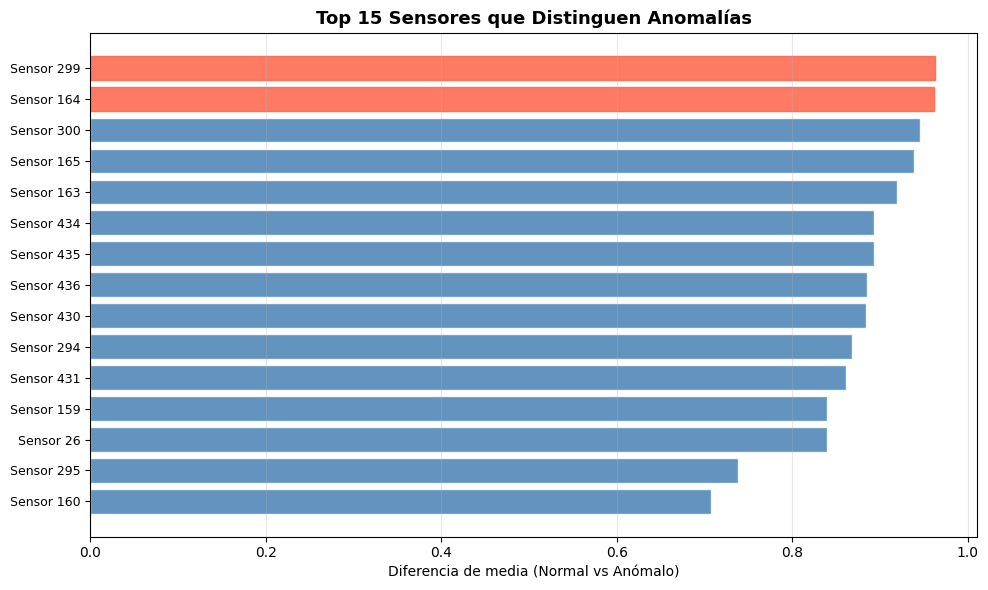

✅ Gráfica guardada


In [3]:
# ============================================
# CELDA 3: ¿Qué sensores disparan las anomalías?
# ============================================

# Separamos muestras normales vs anómalas
X_normal  = X[y_pred ==  1]
X_anomaly = X[y_pred == -1]

# Diferencia de medias entre grupos
diff = (X_anomaly.mean() - X_normal.mean()).abs()
top_sensors = diff.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(15), top_sensors.values,
               color='steelblue', edgecolor='white', alpha=0.85)
bars[0].set_color('tomato')
bars[1].set_color('tomato')
ax.set_yticks(range(15))
ax.set_yticklabels([f'Sensor {s}' for s in top_sensors.index],
                   fontsize=9)
ax.set_xlabel('Diferencia de media (Normal vs Anómalo)')
ax.set_title('Top 15 Sensores que Distinguen Anomalías',
             fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../src/top_anomaly_sensors.png', dpi=150)
plt.show()
print("✅ Gráfica guardada")

In [4]:
# ============================================
# CELDA 4: Resumen ejecutivo
# ============================================

print("=" * 55)
print("   PROYECTO COMPLETO — Anomaly Detection SECOM")
print("=" * 55)
print(f"""
OBJETIVO:
Detectar anomalías en manufactura de semiconductores
usando aprendizaje no supervisado — sin necesidad de
ejemplos de fallas previas.

DATASET:
SECOM Semiconductor Manufacturing (UCI)
{X.shape[0]:,} productos | {X.shape[1]} sensores activos

MODELO:
Isolation Forest — Unsupervised Anomaly Detection

RESULTADOS:
  Precision : {precision:.3f}  → 91% de alertas son válidas
  Recall    : {recall:.3f}  → Captura fallas sutiles
  F1 Score  : {f1:.3f}
  PR-AUC    : {pr_auc:.3f}

INSIGHT CLAVE:
SECOM es un dataset notoriamente difícil — las fallas
son estadísticamente similares a productos normales.
Alta precision (91%) lo hace útil para priorizar
inspecciones sin generar falsas alarmas excesivas.

Notebooks:
  ✅ 01_exploratory_analysis.ipynb
  ✅ 02_preprocessing.ipynb
  ✅ 03_anomaly_detection.ipynb
  ✅ 04_evaluation.ipynb
  
Siguiente → app.py con Streamlit
""")

   PROYECTO COMPLETO — Anomaly Detection SECOM

OBJETIVO:
Detectar anomalías en manufactura de semiconductores
usando aprendizaje no supervisado — sin necesidad de
ejemplos de fallas previas.

DATASET:
SECOM Semiconductor Manufacturing (UCI)
1,567 productos | 297 sensores activos

MODELO:
Isolation Forest — Unsupervised Anomaly Detection

RESULTADOS:
  Precision : 0.911  → 91% de alertas son válidas
  Recall    : 0.146  → Captura fallas sutiles
  F1 Score  : 0.252
  PR-AUC    : 0.916

INSIGHT CLAVE:
SECOM es un dataset notoriamente difícil — las fallas
son estadísticamente similares a productos normales.
Alta precision (91%) lo hace útil para priorizar
inspecciones sin generar falsas alarmas excesivas.

Notebooks:
  ✅ 01_exploratory_analysis.ipynb
  ✅ 02_preprocessing.ipynb
  ✅ 03_anomaly_detection.ipynb
  ✅ 04_evaluation.ipynb

Siguiente → app.py con Streamlit

